In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
from scipy import stats
from scipy.stats import norm
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['sample_submission.csv', 'data_description.txt', 'train.csv', 'test.csv']


In [4]:
df_train=pd.read_csv('../input/train.csv')
df_train.shape

(1460, 81)

In [5]:
df_test=pd.read_csv('../input/test.csv')
df_test.shape

(1459, 80)

In [6]:
df_test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [7]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
df_test.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [11]:
df_train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

*varibale Analysis**

<Axes: xlabel='SalePrice', ylabel='Density'>

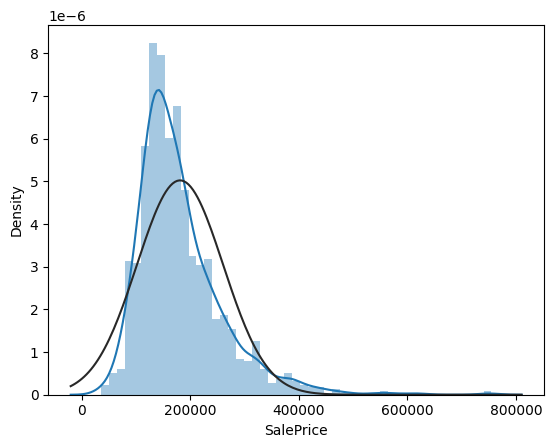

In [12]:
# Traget Varibale
sns.distplot(df_train['SalePrice'],fit=norm)

<Axes: xlabel='SalePrice', ylabel='Density'>

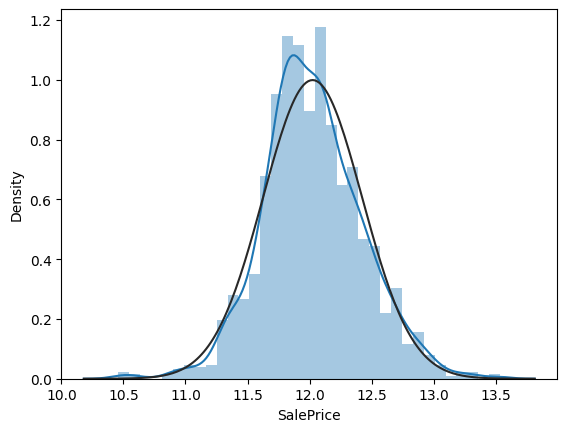

In [13]:
df_train['SalePrice']=np.log(df_train['SalePrice'])
sns.distplot(df_train['SalePrice'],fit=norm)

In [14]:
df_test.shape

(1459, 80)

In [15]:
df_train = pd.read_csv('../input/train.csv')
df_train.shape

(1460, 81)

In [16]:
Q1 = df_train['SalePrice'].quantile(0.25)
Q2 = df_train['SalePrice'].quantile(0.50) 
Q3 = df_train['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 129975.0
Q2: 163000.0
Q3: 214000.0
IQR: 84025.0


In [17]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 3937.5
Upper Limit: 340037.5


In [18]:
outliers = df_train[(df_train['SalePrice'] < lower_limit) | (df_train['SalePrice'] > upper_limit)]

In [19]:
print(outliers)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
11      12          60       RL         85.0    11924   Pave   NaN      IR1   
53      54          20       RL         68.0    50271   Pave   NaN      IR1   
58      59          60       RL         66.0    13682   Pave   NaN      IR2   
112    113          60       RL         77.0     9965   Pave   NaN      Reg   
151    152          20       RL        107.0    13891   Pave   NaN      Reg   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1268  1269          50       RL          NaN    14100   Pave   NaN      IR1   
1353  1354          50       RL         56.0    14720   Pave   NaN      IR1   
1373  1374          20       RL          NaN    11400   Pave   NaN      Reg   
1388  1389          20       RL         42.0    14892   Pave   NaN      IR1   
1437  1438          20       RL         96.0    12444   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC Fen

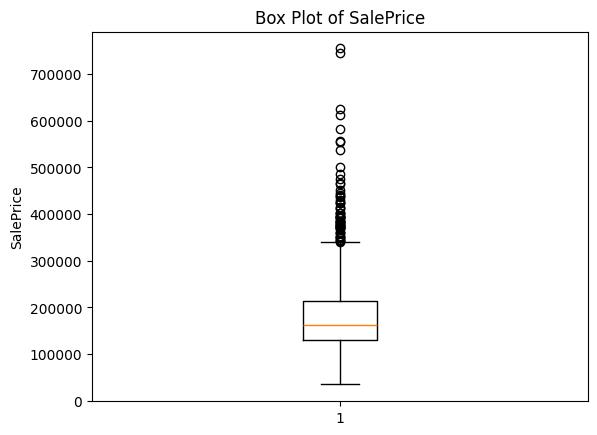

In [20]:
import matplotlib.pyplot as plt

plt.boxplot(df_train['SalePrice'])
plt.title("Box Plot of SalePrice")
plt.ylabel("SalePrice")
plt.show()

In [21]:
df_test['GarageArea'].isnull().sum()
df_test['GarageArea']=df_test['GarageArea'].fillna(df_test['GarageArea'].mean(skipna=True))

In [22]:
df_train['GarageArea'].isnull().sum()

np.int64(0)

<Axes: xlabel='GarageArea', ylabel='Density'>

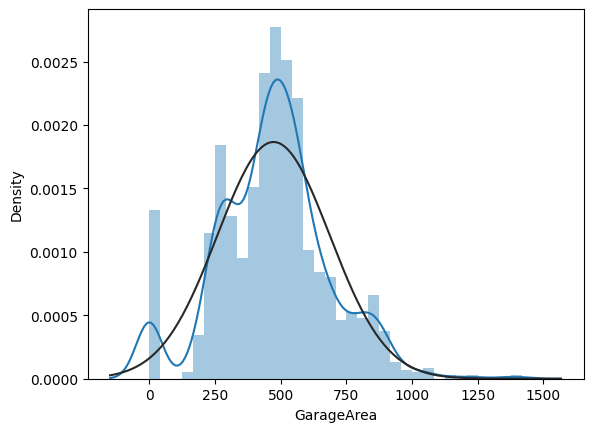

In [23]:
sns.distplot(df_train['GarageArea'],fit=norm)

Text(0, 0.5, 'gargearea')

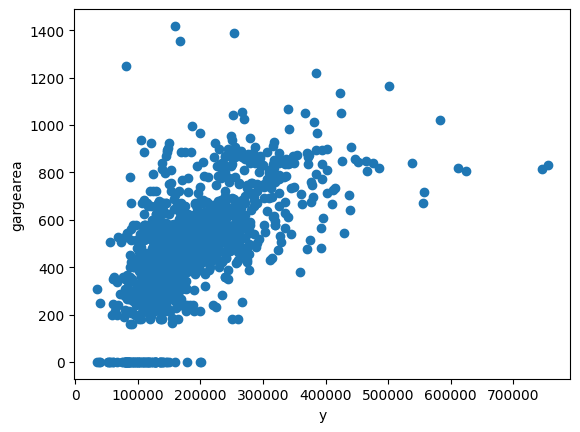

In [24]:
plt.scatter(x=df_train['SalePrice'],y=df_train['GarageArea'])
plt.xlabel('y')
plt.ylabel('gargearea')

In [25]:
df_train['GarageArea']=df_train['GarageArea'].replace(0,df_train['GarageArea'].mean())

<Axes: xlabel='GarageArea', ylabel='Density'>

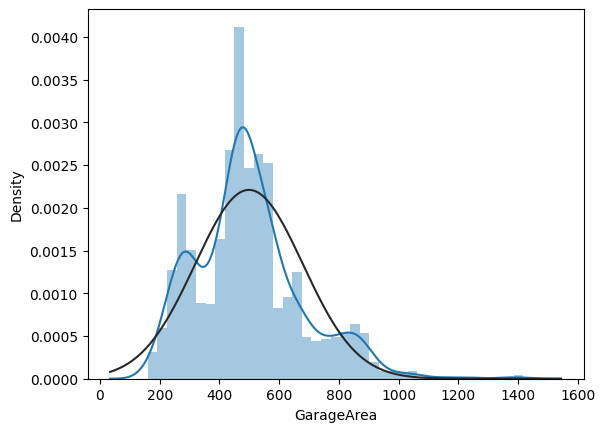

In [26]:
sns.distplot(df_train['GarageArea'],fit=norm)

<Axes: xlabel='GarageArea', ylabel='Density'>

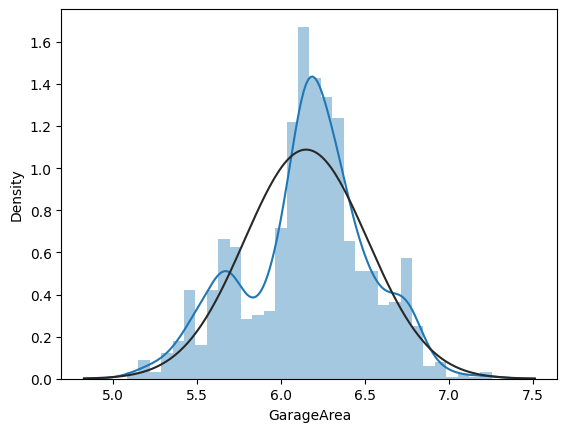

In [27]:
df_train['GarageArea']=np.log(df_train['GarageArea']+1)
sns.distplot(df_train['GarageArea'],fit=norm)

Text(0, 0.5, 'GarageArea')

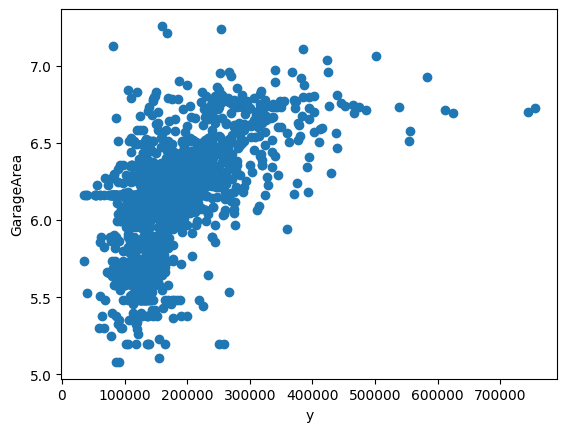

In [28]:
plt.scatter(x=df_train['SalePrice'],y=df_train['GarageArea'])
plt.xlabel('y')
plt.ylabel('GarageArea')

In [29]:
df_test['WoodDeckSF'].isnull().sum()

np.int64(0)

In [30]:
df_train['WoodDeckSF'].isnull().sum()

np.int64(0)

<Axes: xlabel='WoodDeckSF', ylabel='Density'>

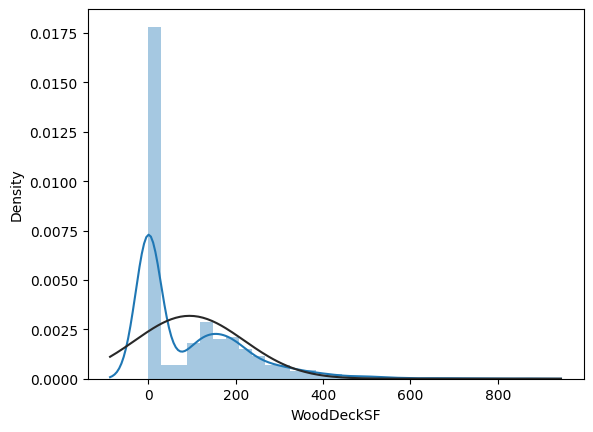

In [31]:
sns.distplot(df_train['WoodDeckSF'],fit=norm)

Text(0, 0.5, 'wooddeckf')

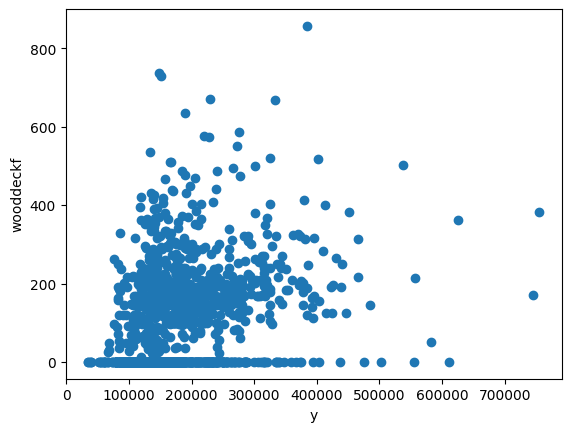

In [32]:
plt.scatter(x=df_train['SalePrice'],y=df_train['WoodDeckSF'])
plt.xlabel('y')
plt.ylabel('wooddeckf')

In [33]:
df_train['WoodDeckSF']=df_train['WoodDeckSF'].replace(0,df_train['WoodDeckSF'].mean())

<Axes: xlabel='WoodDeckSF', ylabel='Density'>

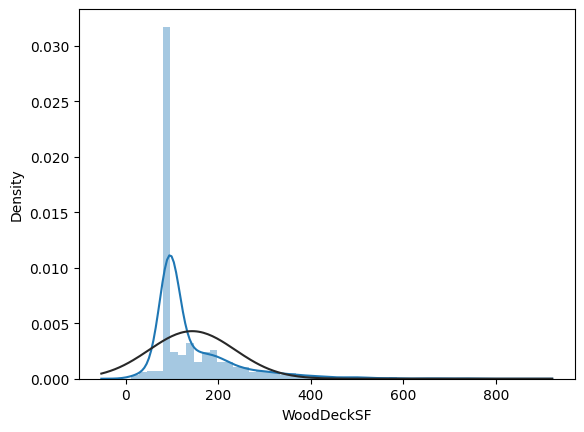

In [34]:
sns.distplot(df_train['WoodDeckSF'],fit=norm)

<Axes: xlabel='WoodDeckSF', ylabel='Density'>

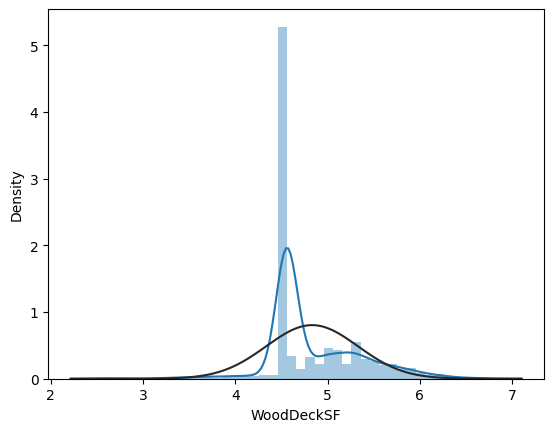

In [35]:
df_train['WoodDeckSF']=np.log(df_train['WoodDeckSF']+1)
sns.distplot(df_train['WoodDeckSF'],fit=norm)

Text(0, 0.5, 'woodDescSF')

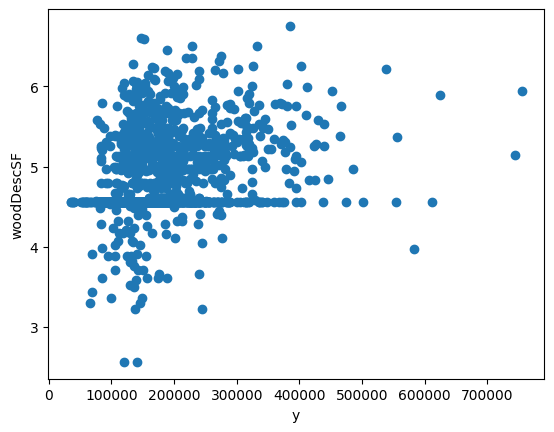

In [36]:
plt.scatter(x=df_train['SalePrice'],y=df_train['WoodDeckSF'])
plt.xlabel('y')
plt.ylabel('woodDescSF')

In [37]:
df_test['OpenPorchSF'].isnull().sum()

np.int64(0)

In [38]:
df_train['OpenPorchSF'].isnull().sum()

np.int64(0)

<Axes: xlabel='OpenPorchSF', ylabel='Density'>

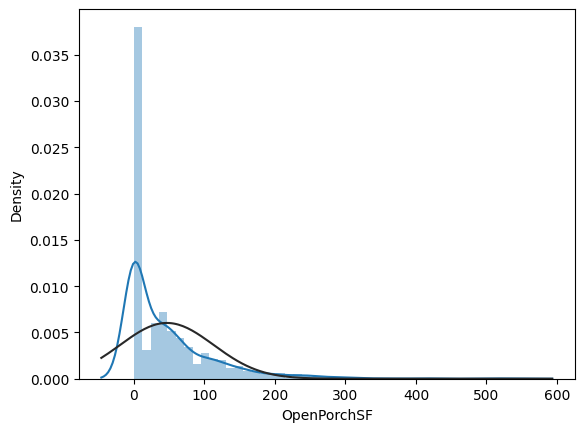

In [39]:
sns.distplot(df_train['OpenPorchSF'],fit=norm)

Text(0, 0.5, 'openporchsf')

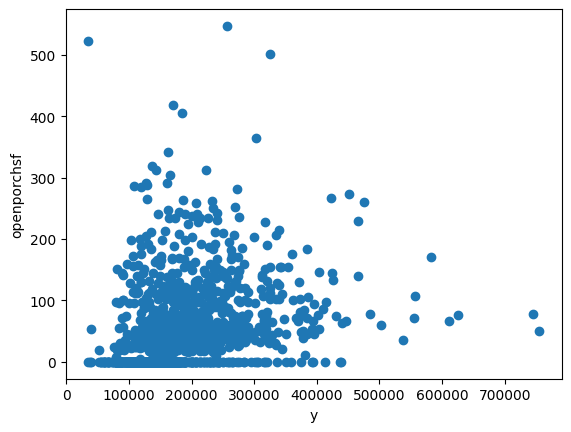

In [40]:
plt.scatter(x=df_train['SalePrice'],y=df_train['OpenPorchSF'])
plt.xlabel('y')
plt.ylabel('openporchsf')

In [41]:
df_train['OpenPorchSF']=df_train['OpenPorchSF'].replace(0,df_train['OpenPorchSF'].mean())

<Axes: xlabel='OpenPorchSF', ylabel='Density'>

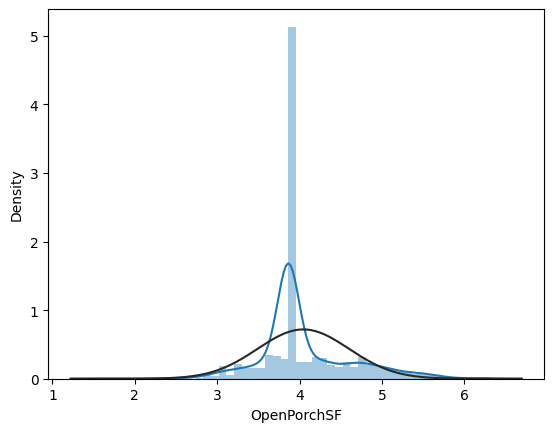

In [42]:
df_train['OpenPorchSF']=np.log(df_train['OpenPorchSF']+1)
sns.distplot(df_train['OpenPorchSF'],fit=norm)

In [43]:
df_test['EnclosedPorch'].isnull().sum()

np.int64(0)

In [44]:
df_train['EnclosedPorch'].isnull().sum()

np.int64(0)

<Axes: xlabel='EnclosedPorch', ylabel='Density'>

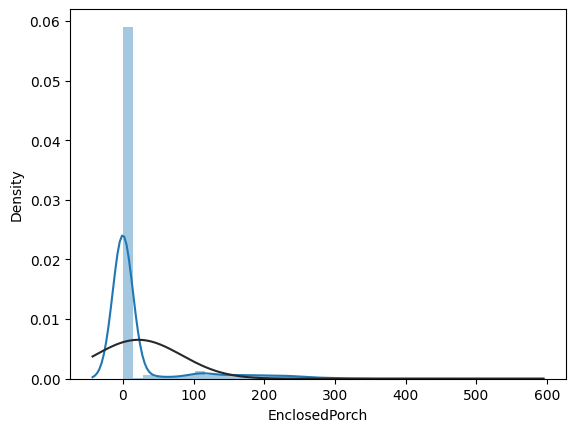

In [45]:
sns.distplot(df_train['EnclosedPorch'],fit=norm)

Text(0, 0.5, 'EnclosedPorch')

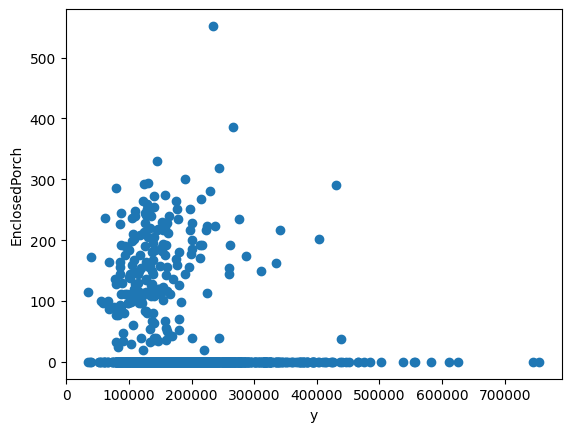

In [46]:
plt.scatter(x=df_train['SalePrice'],y=df_train['EnclosedPorch'])
plt.xlabel('y')
plt.ylabel('EnclosedPorch')

In [47]:
df_train['EnclosedPorch']=df_train['EnclosedPorch'].replace(0,df_train['EnclosedPorch'].mean())

<Axes: xlabel='EnclosedPorch', ylabel='Density'>

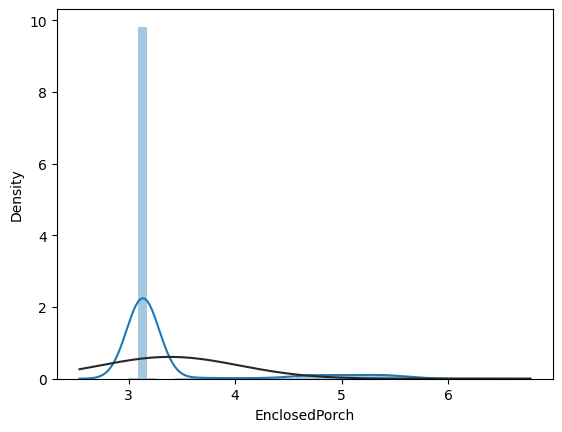

In [48]:
df_train['EnclosedPorch']=np.log(df_train['EnclosedPorch']+1)
sns.distplot(df_train['EnclosedPorch'],fit=norm)

In [49]:
df_test['3SsnPorch'].isnull().sum()

np.int64(0)

In [50]:
df_train['3SsnPorch'].isnull().sum()

np.int64(0)

<Axes: xlabel='3SsnPorch', ylabel='Density'>

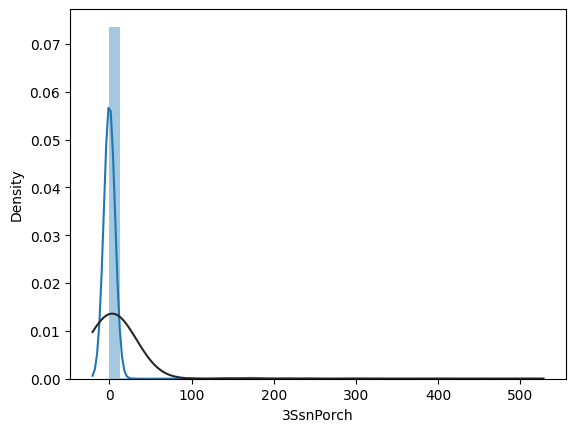

In [51]:
sns.distplot(df_train['3SsnPorch'],fit=norm)

Text(0, 0.5, '3SsnPorch')

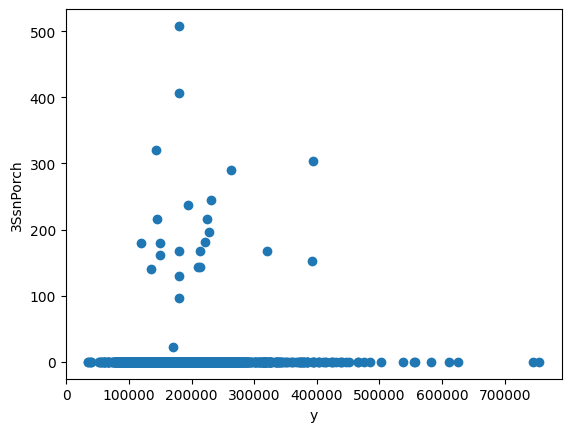

In [52]:
plt.scatter(x=df_train['SalePrice'],y=df_train['3SsnPorch'])
plt.xlabel('y')
plt.ylabel('3SsnPorch')

In [53]:
df_train['3SsnPorch']=df_train['3SsnPorch'].replace(0,df_train['3SsnPorch'].mean())

<Axes: xlabel='3SsnPorch', ylabel='Density'>

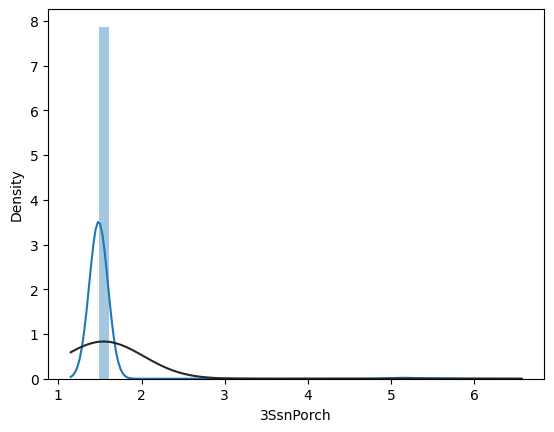

In [54]:
df_train['3SsnPorch']=np.log(df_train['3SsnPorch']+1)
sns.distplot(df_train['3SsnPorch'],fit=norm)

In [55]:
df_test['ScreenPorch'].isnull().sum()

np.int64(0)

In [56]:
df_train['ScreenPorch'].isnull().sum()

np.int64(0)

<Axes: xlabel='ScreenPorch', ylabel='Density'>

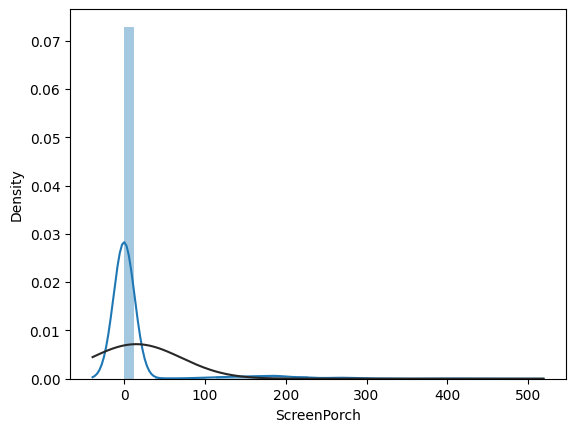

In [57]:
sns.distplot(df_train['ScreenPorch'],fit=norm)

Text(0, 0.5, 'ScreenPorch')

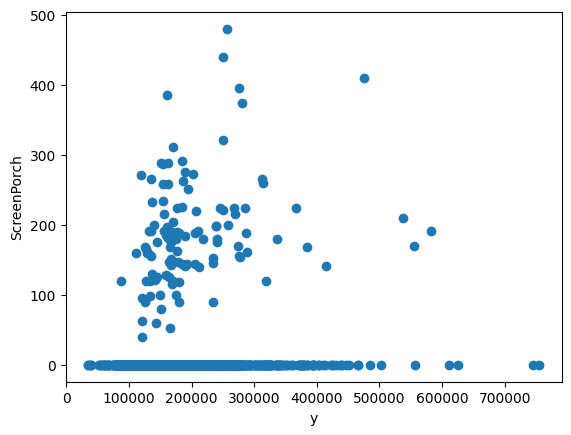

In [58]:
plt.scatter(x=df_train['SalePrice'],y=df_train['ScreenPorch'])
plt.xlabel('y')
plt.ylabel('ScreenPorch')

In [59]:
df_train['ScreenPorch']=df_train['ScreenPorch'].replace(0,df_train['ScreenPorch'].mean())

<Axes: xlabel='ScreenPorch', ylabel='Density'>

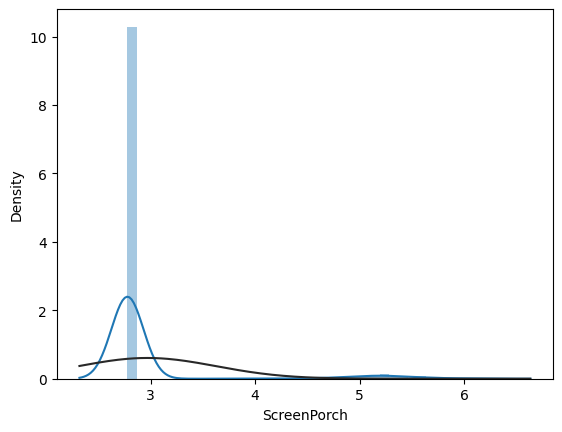

In [60]:
df_train['ScreenPorch']=np.log(df_train['ScreenPorch']+1)
sns.distplot(df_train['ScreenPorch'],fit=norm)

In [61]:
df_test['PoolArea'].isnull().sum()

np.int64(0)

In [62]:
df_train['PoolArea'].isnull().sum()

np.int64(0)

<Axes: xlabel='PoolArea', ylabel='Density'>

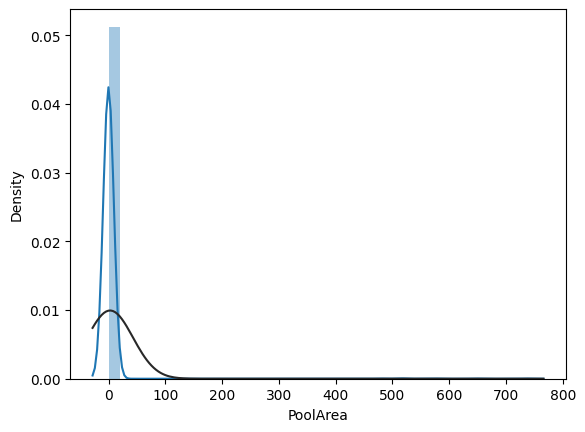

In [63]:
sns.distplot(df_train['PoolArea'],fit=norm)

Text(0, 0.5, 'poolarea')

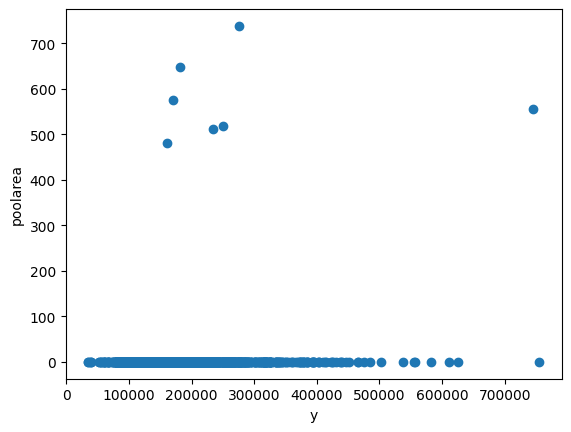

In [64]:
plt.scatter(x=df_train['SalePrice'],y=df_train['PoolArea'])
plt.xlabel('y')
plt.ylabel('poolarea')

In [65]:
df_train['PoolArea']=df_train['PoolArea'].replace(0,df_train['PoolArea'].mean())

<Axes: xlabel='PoolArea', ylabel='Density'>

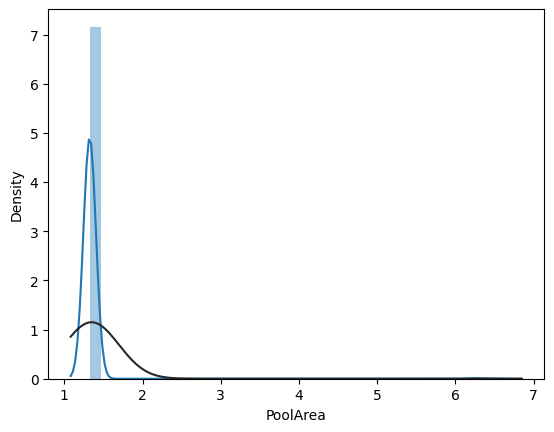

In [66]:
df_train['PoolArea']=np.log(df_train['PoolArea']+1)
sns.distplot(df_train['PoolArea'],fit=norm)

In [67]:
df_train['MiscVal'].isnull().sum()

np.int64(0)

<Axes: xlabel='MiscVal', ylabel='Density'>

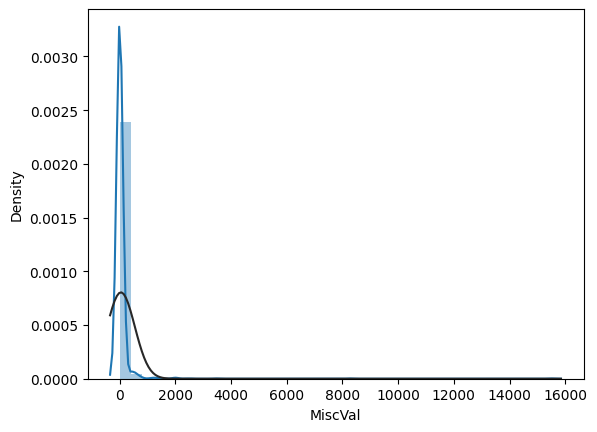

In [68]:
sns.distplot(df_train['MiscVal'],fit=norm)

Text(0, 0.5, 'MiscVal')

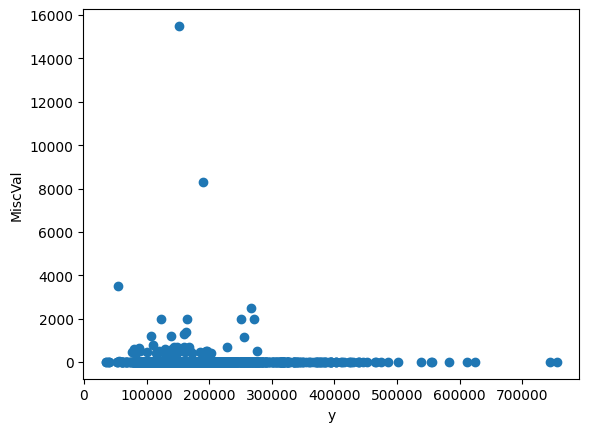

In [69]:
plt.scatter(x=df_train['SalePrice'],y=df_train['MiscVal'])
plt.xlabel('y')
plt.ylabel('MiscVal')

In [70]:
df_test['MiscVal'].isnull().sum()

np.int64(0)

<Axes: xlabel='MiscVal', ylabel='Density'>

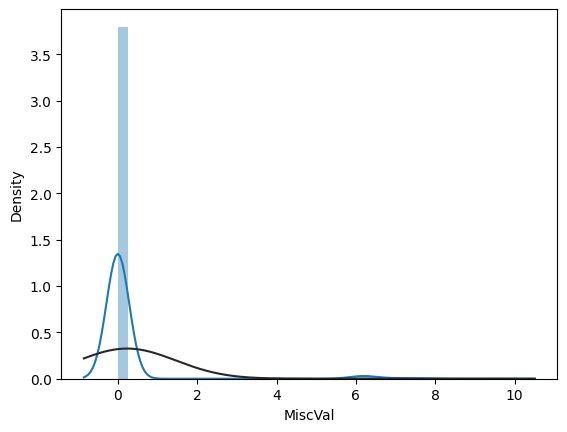

In [71]:
df_train['MiscVal']=np.log(df_train['MiscVal']+1)
sns.distplot(df_train['MiscVal'],fit=norm)

In [72]:
df_test['MoSold'].isnull().sum()

np.int64(0)

<Axes: xlabel='MoSold', ylabel='Density'>

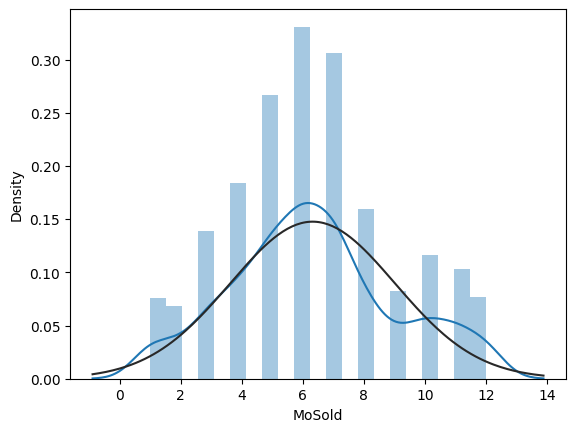

In [73]:
sns.distplot(df_train['MoSold'],fit=norm)

Text(0, 0.5, 'MoSold')

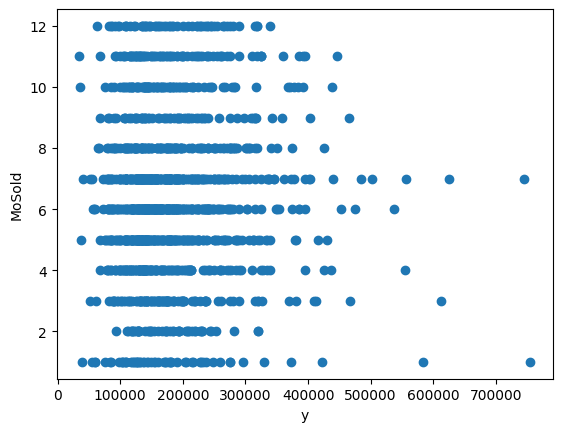

In [74]:
plt.scatter(x=df_train['SalePrice'],y=df_train['MoSold'])
plt.xlabel('y')
plt.ylabel('MoSold')

In [75]:
df_test['YrSold'].isnull().sum()

np.int64(0)

In [76]:
df_train['YrSold'].isnull().sum()

np.int64(0)

<Axes: xlabel='YrSold', ylabel='Density'>

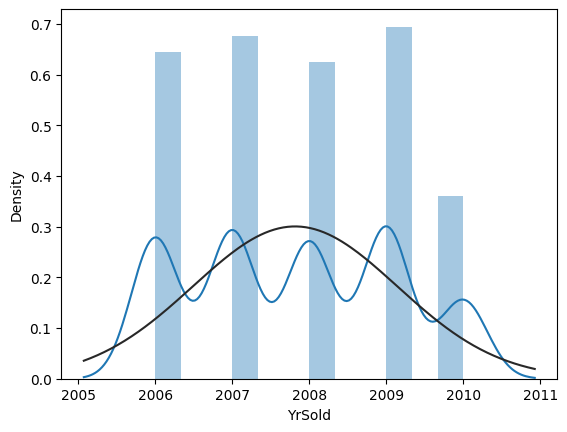

In [77]:
sns.distplot(df_train['YrSold'],fit=norm)

Text(0, 0.5, 'YrSold')

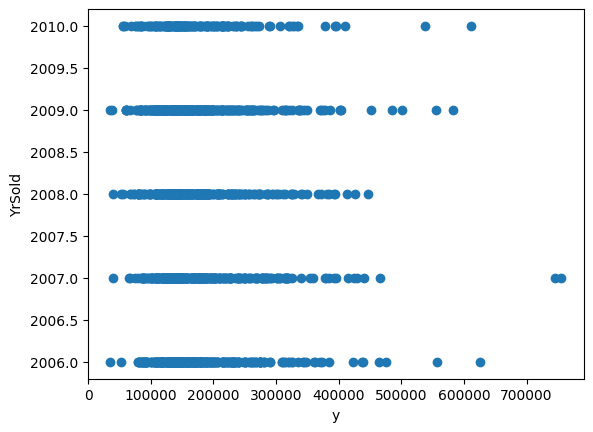

In [78]:
plt.scatter(x=df_train['SalePrice'],y=df_train['YrSold'])
plt.xlabel('y')
plt.ylabel('YrSold')

In [79]:
cont1=df_train.dtypes==np.float64
cont1=df_train.loc[:,cont1]
cont1.columns

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal'],
      dtype='object')

In [80]:
df_train['GarageYrBlt'].isnull().sum()

np.int64(81)

<Axes: ylabel='GarageYrBlt'>

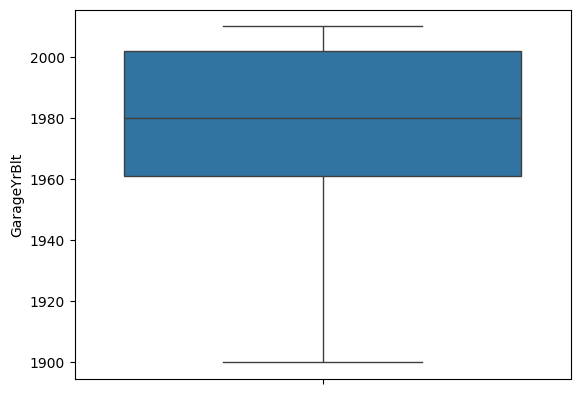

In [81]:
sns.boxplot(df_train['GarageYrBlt'])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96],
 [Text(0, 0, '1900.0'),
  Text(1, 0, '1906.0'),
  Text(2, 0, '1908.0'),
  Text(3, 0, '1910.0'),
  Text(4, 0, '1914.0'),
  Text(5, 0, '1915.0'),
  Text(6, 0, '1916.0'),
  Text(7, 0, '1918.0'),
  Text(8, 0, '1920.0'),
  Text(9, 0, '1921.0'),
  Text(10, 0, '1922.0'),
  Text(11, 0, '1923.0'),
  Text(12, 0, '1924.0'),
  Text(13, 0, '1925.0'),
  Text(14, 0, '1926.0'),
  Text(15, 0, '1927.0'),
  Text(16, 0, '1928.0'),
  Text(17, 0

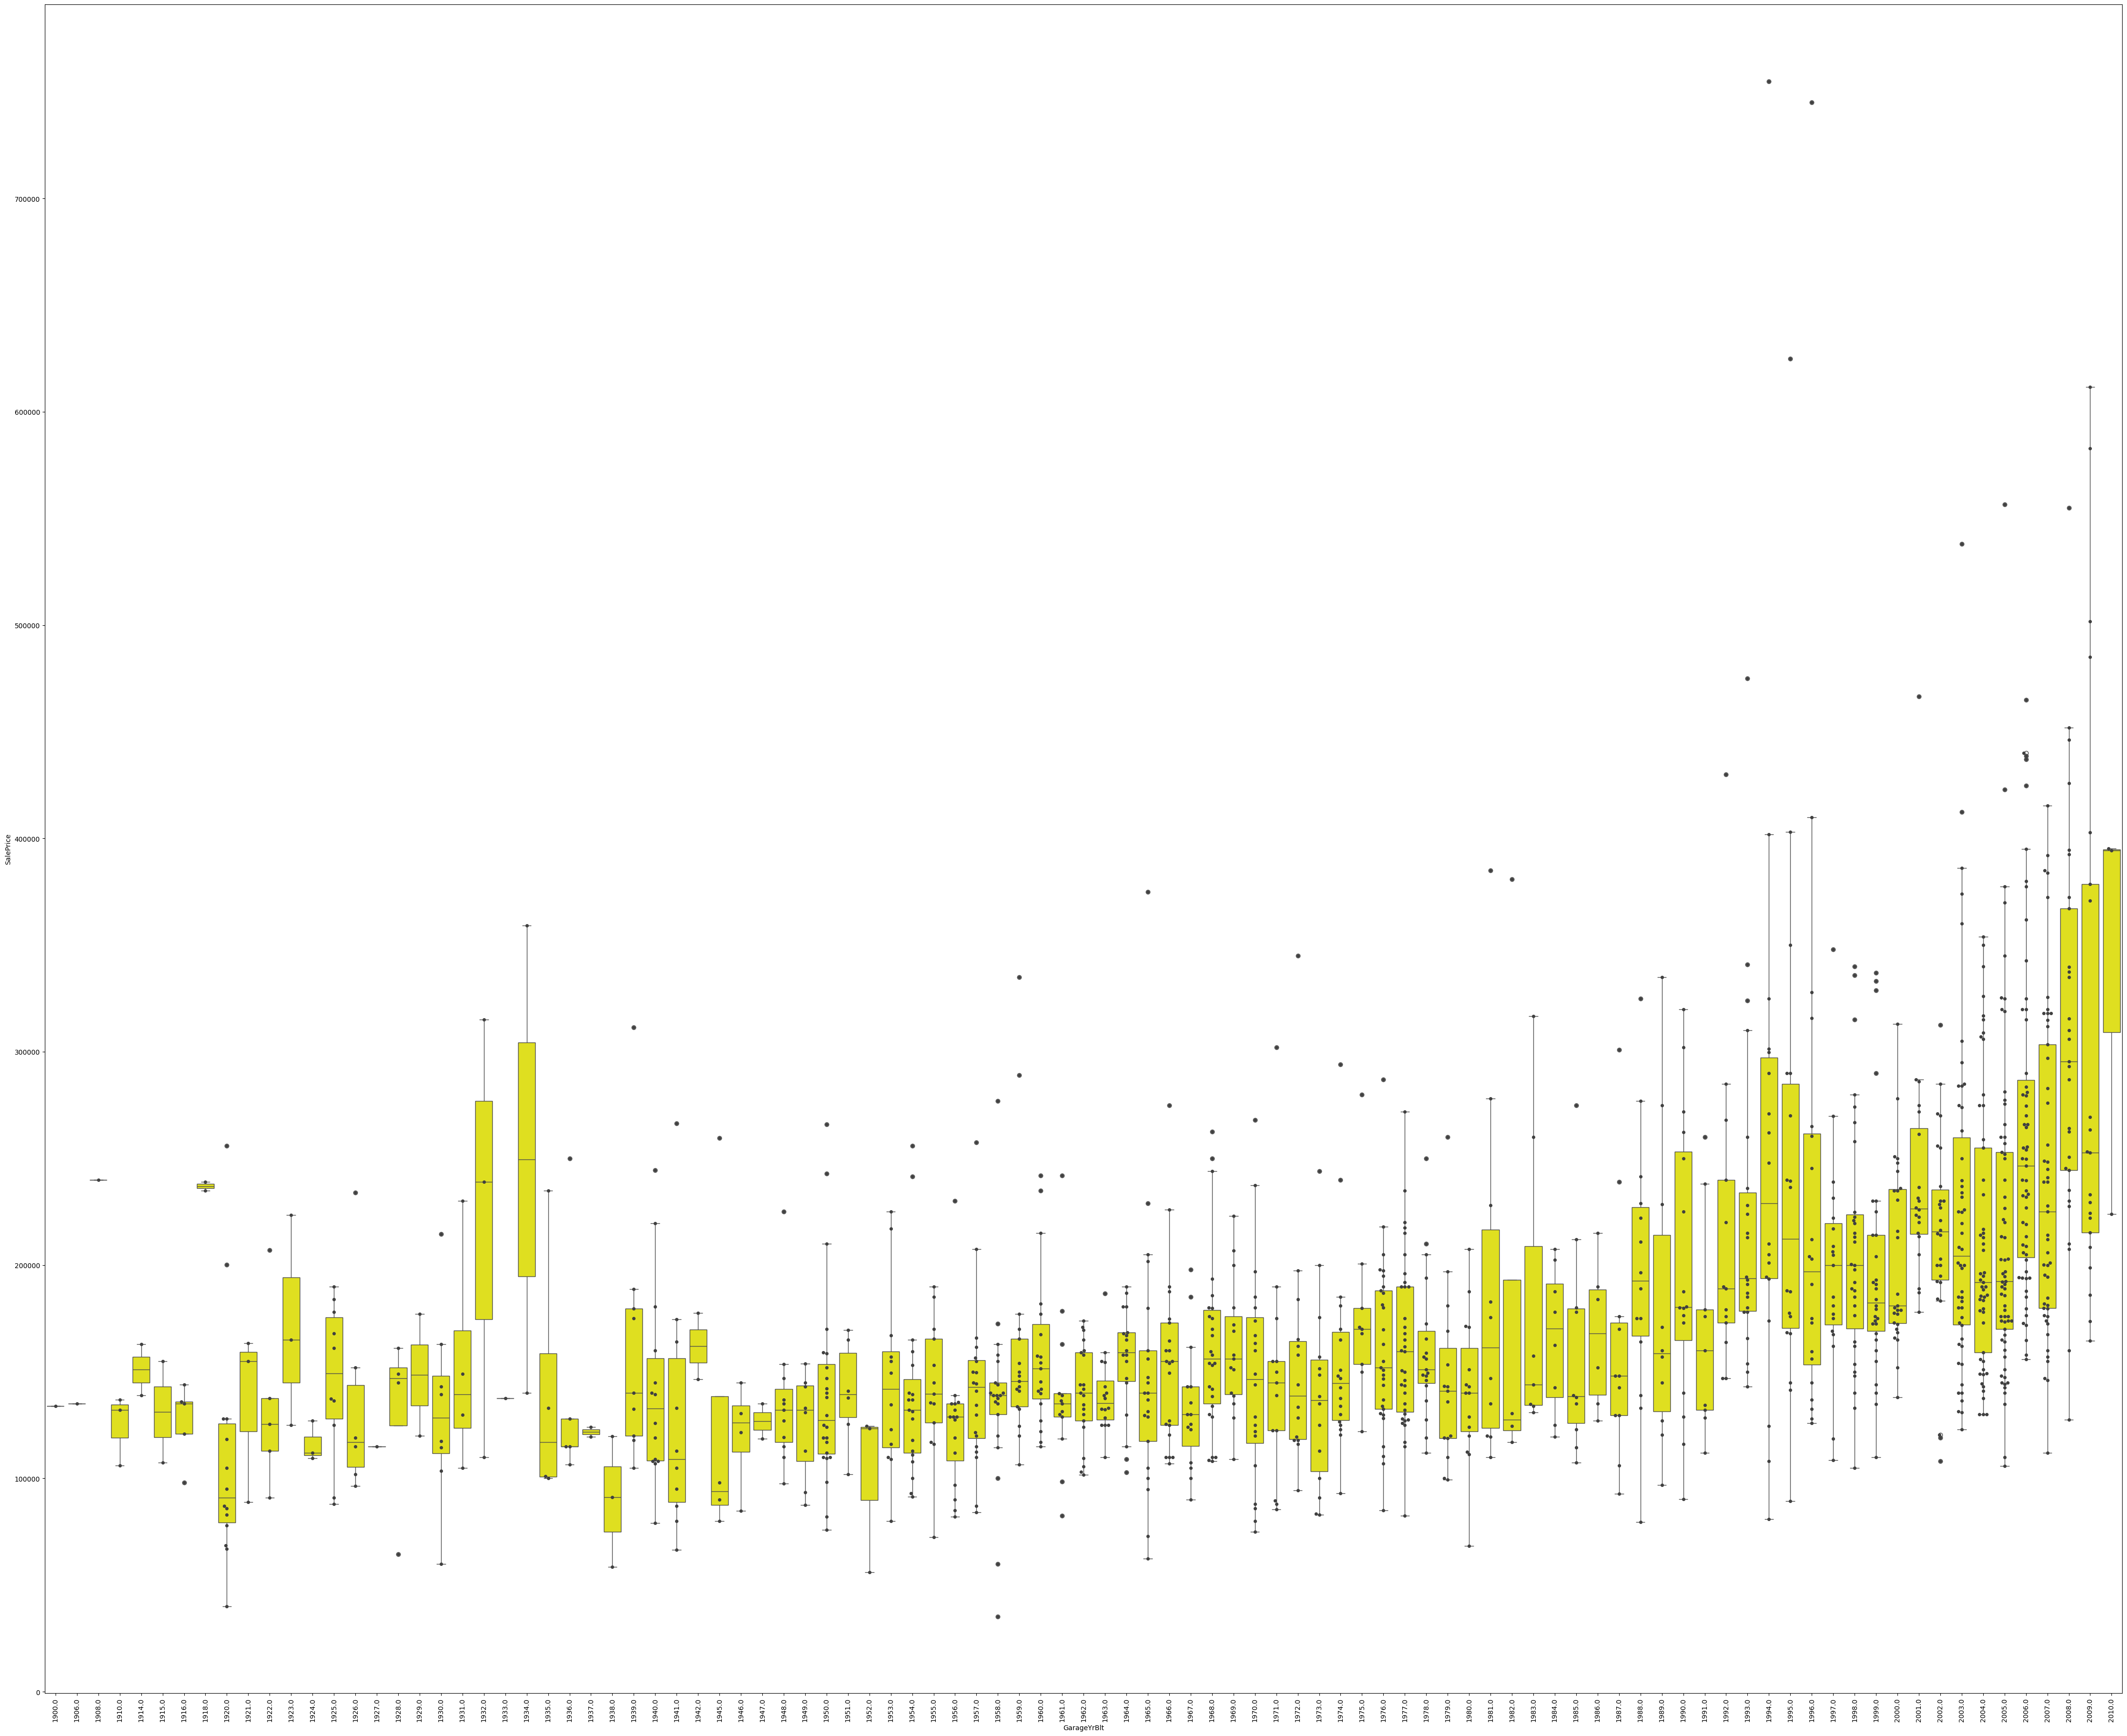

In [82]:
plt.figure(figsize=(55,45))
sns.boxplot(x=df_train['GarageYrBlt'],y=df_train['SalePrice'],color='yellow')
sns.swarmplot(x=df_train['GarageYrBlt'],y=df_train['SalePrice'],color='.25')
plt.xticks(rotation=90)

In [83]:
df_train['GarageYrBlt']=df_train['GarageYrBlt'].fillna(df_train['GarageYrBlt'].median(skipna=True))

In [84]:
df_test['GarageYrBlt'].isnull().sum()
df_test['GarageYrBlt']=df_test['GarageYrBlt'].fillna(df_test['GarageYrBlt'].median(skipna=True))

In [85]:
df_train['MasVnrArea'].isnull().sum()

np.int64(8)

<Axes: ylabel='MasVnrArea'>

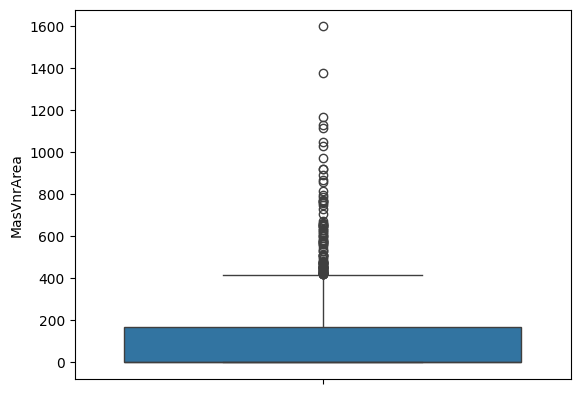

In [86]:
sns.boxplot(df_train['MasVnrArea'])

Text(0, 0.5, 'MasVnrArea')

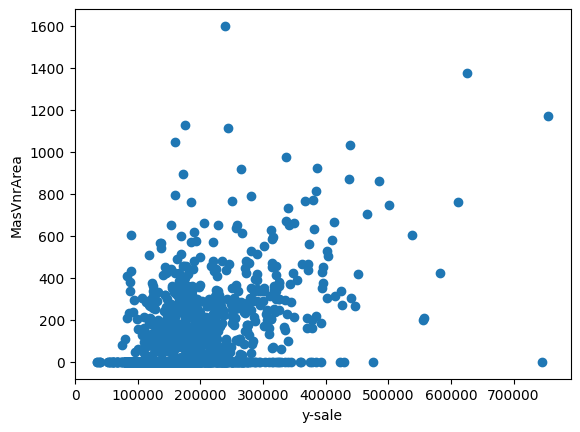

In [87]:
plt.scatter(x=df_train['SalePrice'],y=df_train['MasVnrArea'])
plt.xlabel('y-sale')
plt.ylabel('MasVnrArea')

In [88]:
df_train['MasVnrArea']=df_train['MasVnrArea'].fillna(df_train['MasVnrArea'].mean(skipna=True))

In [89]:
df_test['MasVnrArea'].isnull().sum()
df_test['MasVnrArea']=df_test['MasVnrArea'].fillna(df_test['MasVnrArea'].mean(skipna=True))

In [90]:
df_test['LotFrontage'].isnull().sum()
df_test['LotFrontage']=df_test['LotFrontage'].fillna(df_test['LotFrontage'].mean(skipna=True))

In [91]:
df_train['LotFrontage'].isnull().sum()

np.int64(259)

<Axes: ylabel='LotFrontage'>

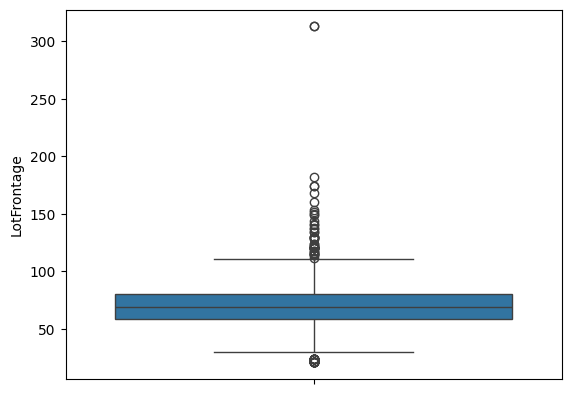

In [92]:
sns.boxplot(df_train['LotFrontage'])

Text(0, 0.5, 'LotFrontage')

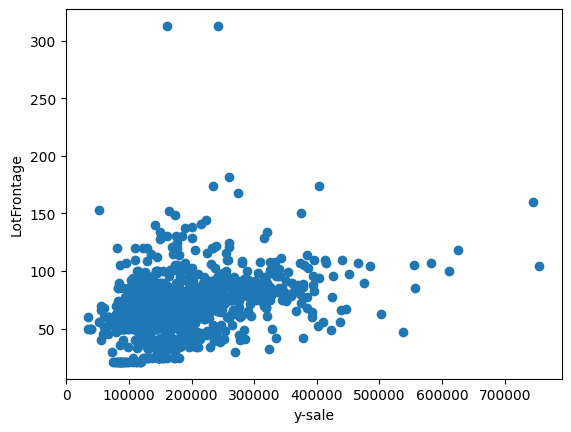

In [93]:
plt.scatter(x=df_train['SalePrice'],y=df_train['LotFrontage'])
plt.xlabel('y-sale')
plt.ylabel('LotFrontage')

In [94]:
df_train['LotFrontage']=df_train['LotFrontage'].fillna(df_train['LotFrontage'].mean(skipna=True))

In [95]:
df_train['LotFrontage'].isna().sum()

np.int64(0)

In [96]:
catg=df_train.dtypes==object
catg=df_train.loc[:,catg]
catg.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [97]:
df_test['MSZoning'].isnull().sum()
df_test['MSZoning']=df_test['MSZoning'].fillna(df_test['MSZoning'].mode()[0])

In [98]:
df_train['MSZoning'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='MSZoning'>

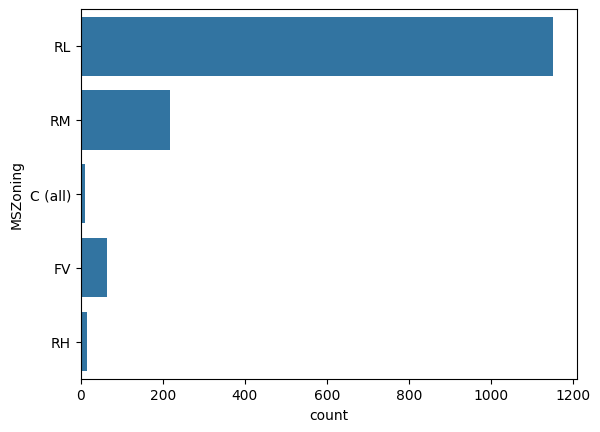

In [99]:
sns.countplot(df_train['MSZoning'])

<Axes: xlabel='MSZoning', ylabel='SalePrice'>

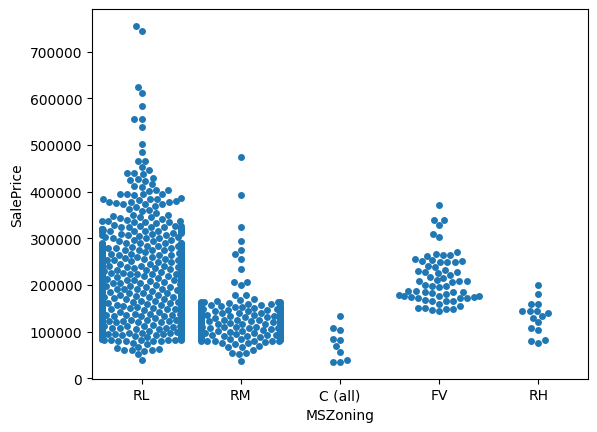

In [100]:
 sns.swarmplot(x=df_train['MSZoning'], y=df_train['SalePrice'])

In [101]:
df_test['Street'].isnull().sum()

np.int64(0)

In [102]:
df_train['Street'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Street'>

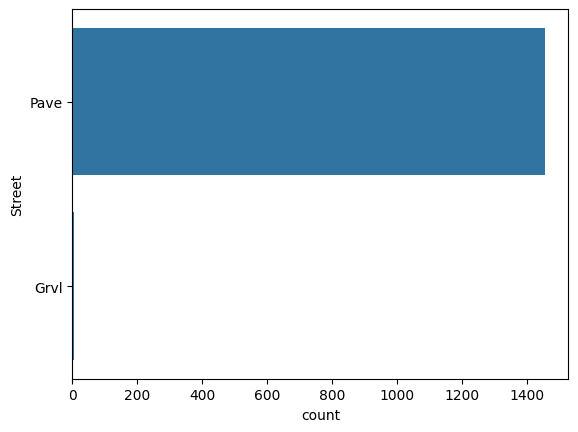

In [103]:
sns.countplot(df_train['Street'])

<Axes: xlabel='Street', ylabel='SalePrice'>

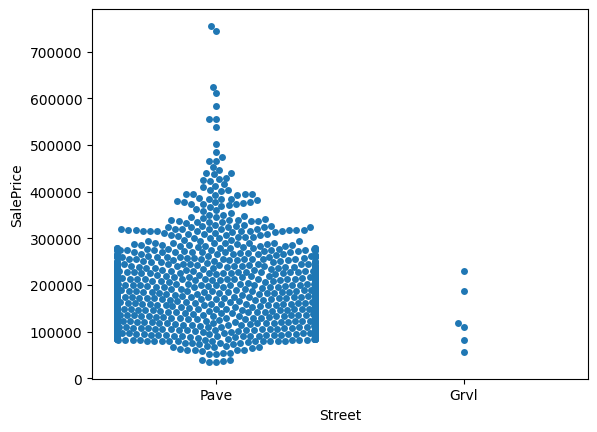

In [104]:
sns.swarmplot(x=df_train['Street'],y=df_train['SalePrice'])

In [105]:
df_train['Alley'].isnull().sum()

np.int64(1369)

In [106]:
df_train=df_train.drop(['Alley'],axis=1)
df_train.shape

(1460, 80)

In [107]:
df_test['Alley'].isnull().sum()

np.int64(1352)

In [108]:
df_test=df_test.drop(['Alley'],axis=1)
df_test.shape

(1459, 79)

In [109]:
df_test['LotShape'].isnull().sum()

np.int64(0)

In [110]:
df_train['LotShape'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='LotShape'>

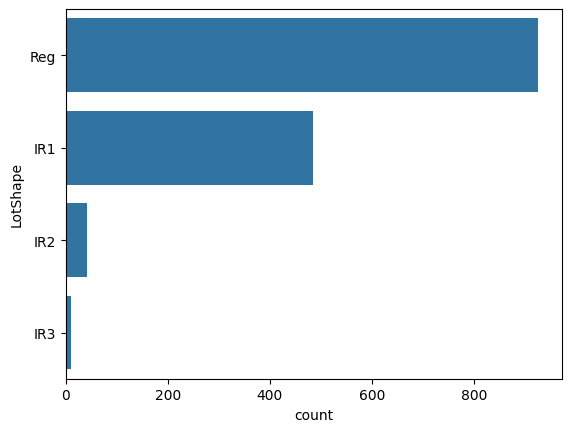

In [111]:
sns.countplot(df_train['LotShape'])

<Axes: xlabel='LotShape', ylabel='SalePrice'>

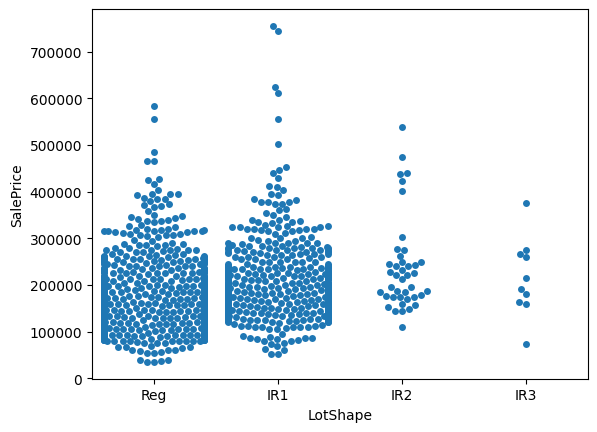

In [112]:
sns.swarmplot(x=df_train['LotShape'],y=df_train['SalePrice'])

In [113]:
df_test['LandContour'].isnull().sum()

np.int64(0)

In [114]:
df_train['LandContour'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='LandContour'>

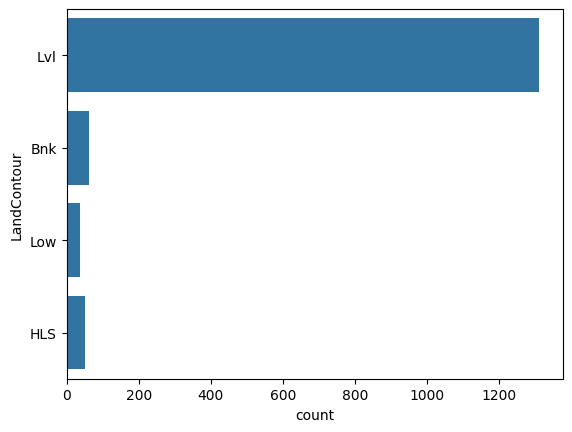

In [115]:
sns.countplot(df_train['LandContour'])

<Axes: xlabel='LandContour', ylabel='SalePrice'>

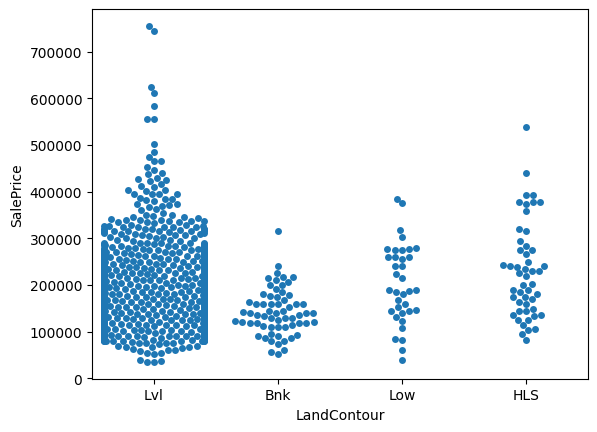

In [116]:
sns.swarmplot(x=df_train['LandContour'],y=df_train['SalePrice'])

In [117]:
df_test['Utilities'].isnull().sum()
df_test['Utilities']=df_test['Utilities'].fillna(df_test['Utilities'].mode()[0])

In [118]:
df_train['Utilities'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Utilities'>

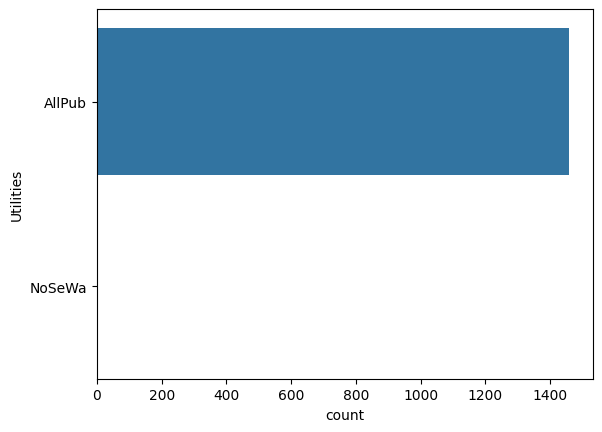

In [119]:
sns.countplot(df_train['Utilities'])

<Axes: xlabel='Utilities', ylabel='SalePrice'>

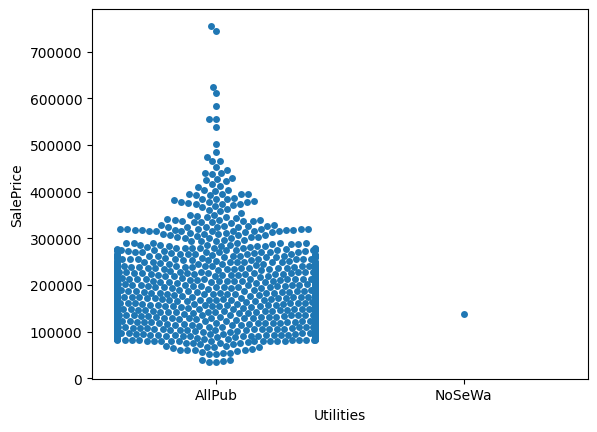

In [120]:
sns.swarmplot(x=df_train['Utilities'],y=df_train['SalePrice'])

In [121]:
df_train['LotConfig'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='LotConfig'>

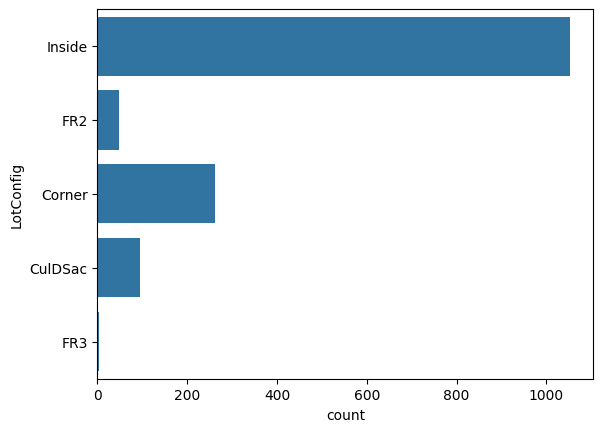

In [122]:
sns.countplot(df_train['LotConfig'])

<Axes: xlabel='LotConfig', ylabel='SalePrice'>

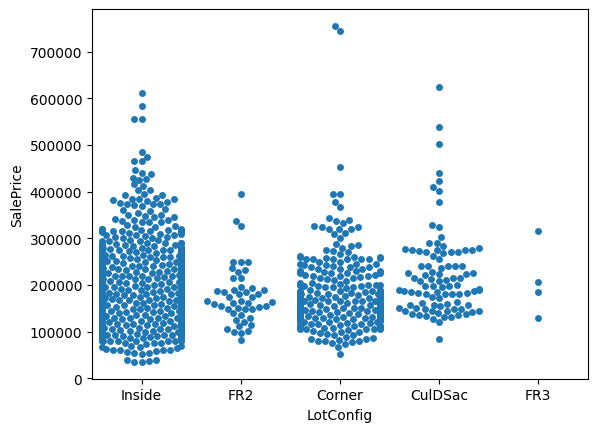

In [123]:
sns.swarmplot(x=df_train['LotConfig'],y=df_train['SalePrice'])

In [124]:
df_test['LandSlope'].isnull().sum()

np.int64(0)

In [125]:
df_train['LandSlope'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='LandSlope'>

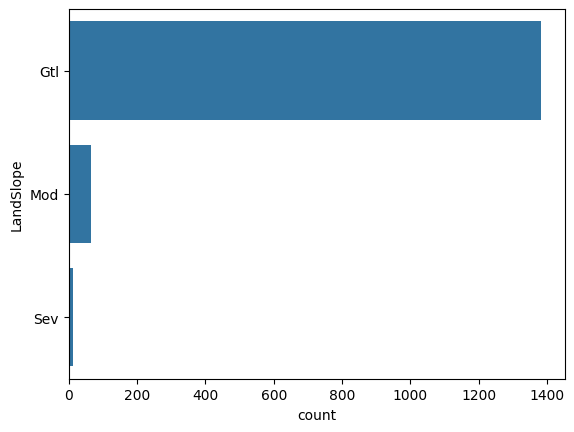

In [126]:
sns.countplot(df_train['LandSlope'])

<Axes: xlabel='LandSlope', ylabel='SalePrice'>

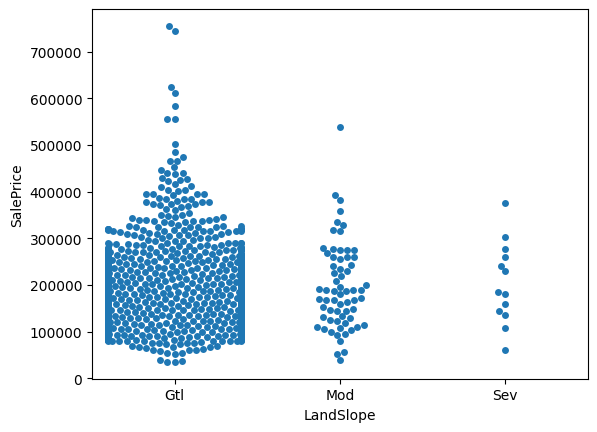

In [127]:
sns.swarmplot(x=df_train['LandSlope'],y=df_train['SalePrice'])

In [128]:
df_test['Neighborhood'].isnull().sum()

np.int64(0)

In [129]:
df_train['Neighborhood'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Neighborhood'>

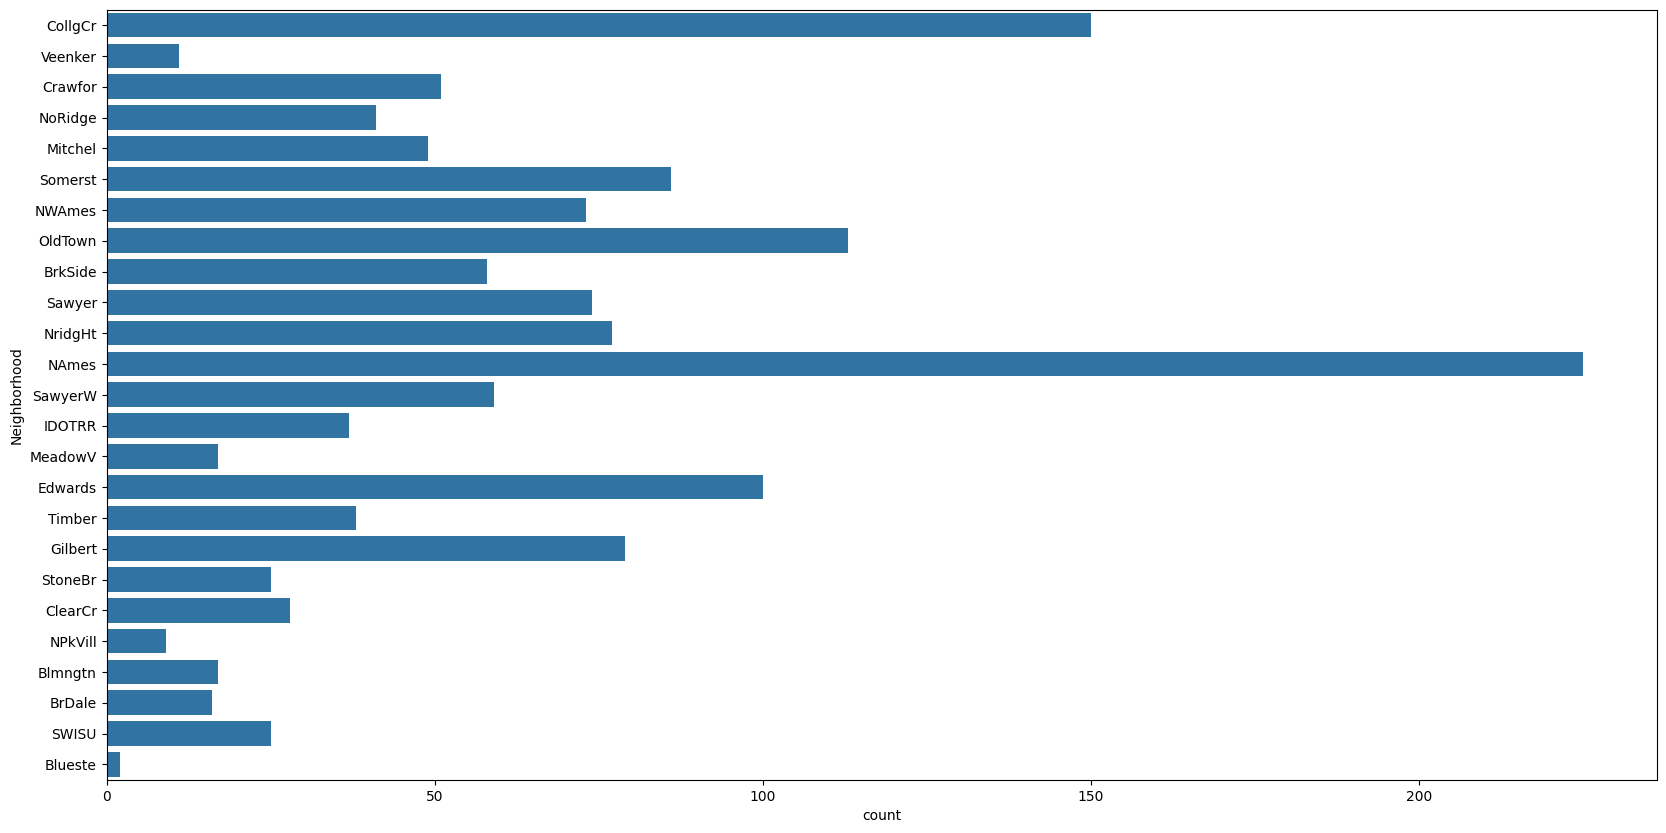

In [130]:
plt.figure(figsize=(20,10))
sns.countplot(df_train['Neighborhood'])

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

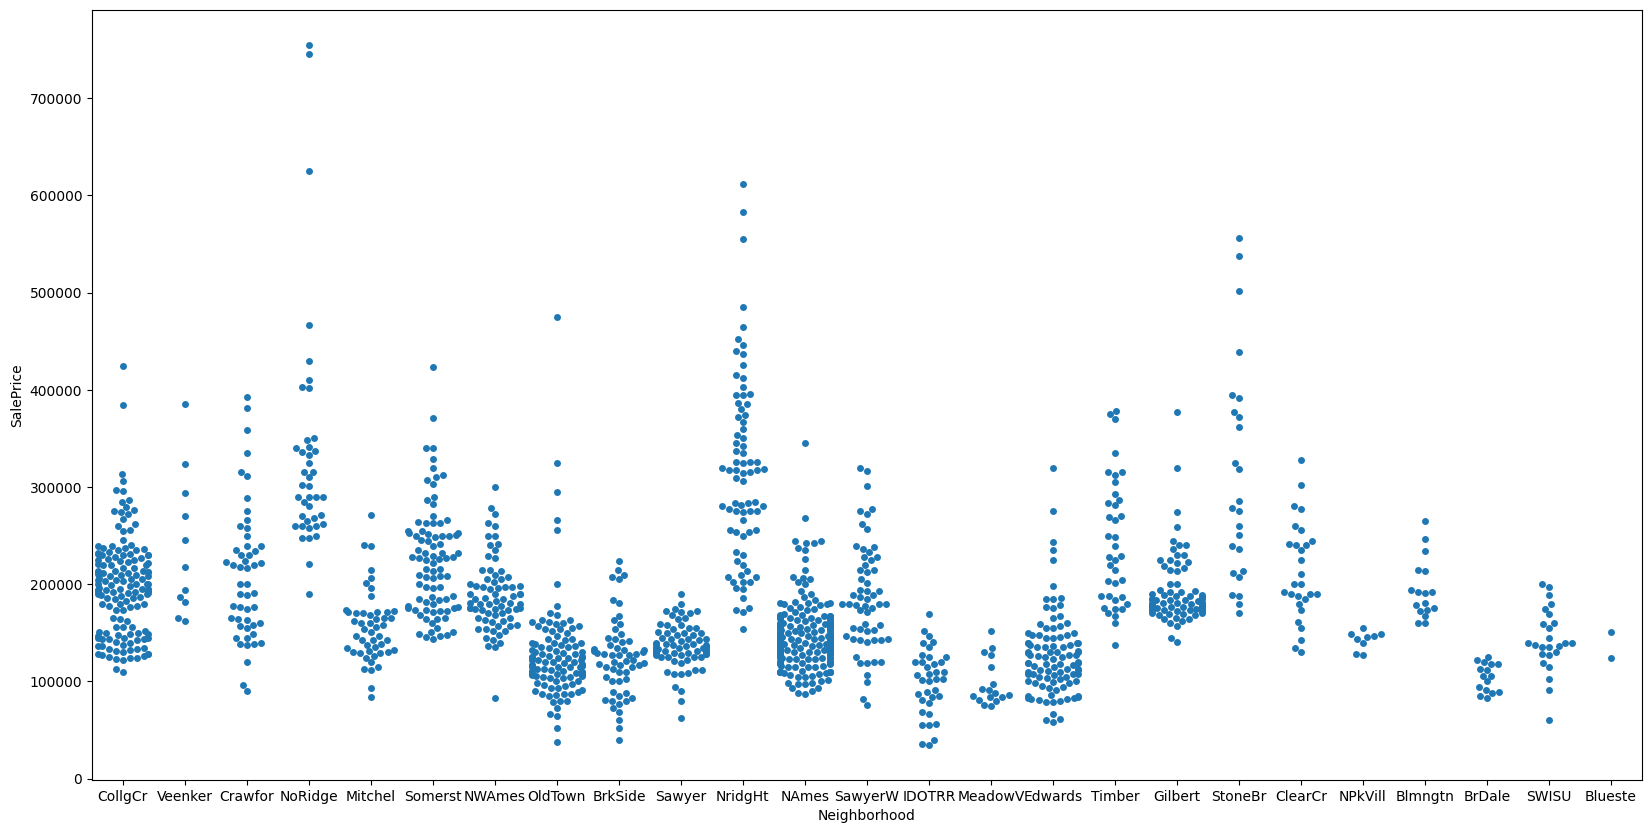

In [131]:
plt.figure(figsize=(20,10))
sns.swarmplot(x=df_train['Neighborhood'],y=df_train['SalePrice'])

In [132]:
df_test['Condition1'].isnull().sum()

np.int64(0)

In [133]:
df_train['Condition1'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Condition1'>

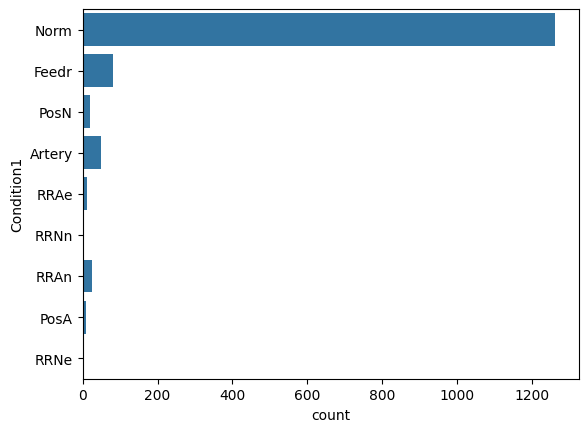

In [134]:
sns.countplot(df_train['Condition1'])

<Axes: xlabel='Condition1', ylabel='SalePrice'>

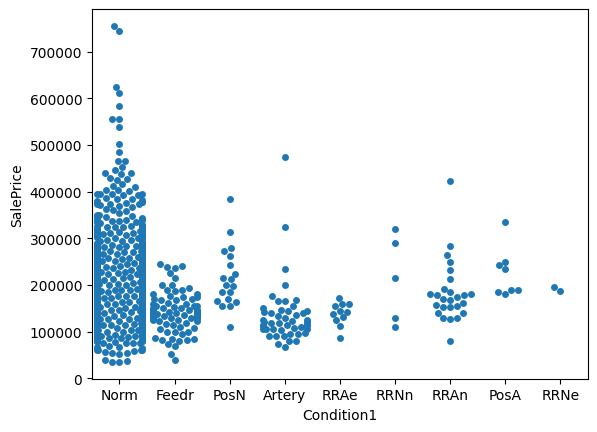

In [135]:
sns.swarmplot(x=df_train['Condition1'],y=df_train['SalePrice'])

In [136]:
df_test['Condition2'].isnull().sum()

np.int64(0)

In [137]:
df_train['Condition2'].isnull().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Condition2'>

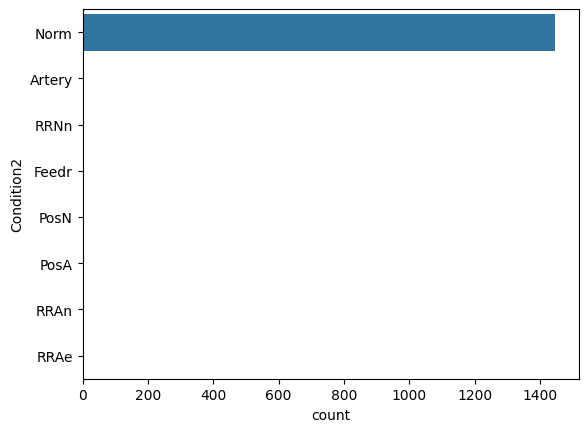

In [138]:
sns.countplot(df_train['Condition2'])

In [ ]:
sns.swarmplot(x=df_train['Condition2'],y=df_train['SalePrice'])

<Axes: xlabel='Condition2', ylabel='SalePrice'>

In [ ]:
df_train['BldgType'].isnull().sum()

In [ ]:
sns.countplot(df_train['BldgType'])

In [ ]:
sns.swarmplot(x=df_train['BldgType'],y=df_train['SalePrice'])

In [ ]:
df_test['HouseStyle'].isnull().sum()

In [ ]:
df_train['HouseStyle'].isnull().sum()

In [ ]:
sns.countplot(df_train['HouseStyle'])

In [ ]:
sns.swarmplot(x=df_train['HouseStyle'],y=df_train['SalePrice'])

In [ ]:
df_test['RoofStyle'].isnull().sum()

In [ ]:
df_train['RoofStyle'].isnull().sum()

In [ ]:
sns.countplot(df_train['RoofStyle'])

In [ ]:
sns.swarmplot(x=df_train['RoofStyle'],y=df_train['SalePrice'])

In [ ]:
df_test['RoofMatl'].isnull().sum()

In [ ]:
df_train['RoofMatl'].isnull().sum()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(df_train['RoofMatl'])

In [ ]:
plt.figure(figsize=(8,5))
sns.swarmplot(x=df_train['RoofMatl'],y=df_train['SalePrice'])

In [ ]:
df_test['Exterior1st'].isnull().sum()
df_test['Exterior1st']=df_test['Exterior1st'].fillna(df_test['Exterior1st'].mode()[0])

In [ ]:
df_train['Exterior1st'].isnull().sum()

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(df_train['Exterior1st'])

In [ ]:
plt.figure(figsize=(15,5))
sns.swarmplot(x=df_train['Exterior1st'],y=df_train['SalePrice'])

In [ ]:
df_test['Exterior2nd'].isnull().sum()
df_test['Exterior2nd']=df_test['Exterior2nd'].fillna(df_test['Exterior2nd'].mode()[0])

In [ ]:
df_train['Exterior2nd'].isnull().sum()

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(df_train['Exterior2nd'])

In [ ]:
plt.figure(figsize=(15,5))
sns.swarmplot(x=df_train['Exterior2nd'],y=df_train['SalePrice'])

In [ ]:
df_test['MasVnrType'].isnull().sum()
df_test['MasVnrType']=df_test['MasVnrType'].fillna(df_test['MasVnrType'].mode()[0])

In [ ]:
df_train['MasVnrType'].isnull().sum()

In [ ]:
sns.countplot(df_train['MasVnrType'])

In [ ]:
sns.swarmplot(x=df_train['MasVnrType'],y=df_train['SalePrice'])

In [ ]:
df_train['MasVnrType']=df_train['MasVnrType'].fillna(df_train['MasVnrType'].mode()[0])

In [ ]:
df_test['ExterQual'].isnull().sum()

In [ ]:
df_train['ExterQual'].isnull().sum()

In [ ]:
sns.countplot(df_train['ExterQual'])

In [ ]:
sns.swarmplot(x=df_train['ExterQual'],y=df_train['SalePrice'])

In [ ]:
df_test['ExterCond'].isnull().sum()

In [ ]:
df_train['ExterCond'].isnull().sum()

In [ ]:
sns.countplot(df_train['ExterCond'])

In [ ]:
sns.swarmplot(x=df_train['ExterCond'],y=df_train['SalePrice'])

In [ ]:
df_test['Foundation'].isnull().sum()

In [ ]:
df_train['Foundation'].isnull().sum()

In [ ]:
sns.countplot(df_train['Foundation'])

In [ ]:
sns.swarmplot(x=df_train['Foundation'],y=df_train['SalePrice'])

In [ ]:
df_test['BsmtQual'].isnull().sum()
df_test['BsmtQual']=df_test['BsmtQual'].fillna(df_test['BsmtQual'].mode()[0])

In [ ]:
df_train['BsmtQual'].isnull().sum()

In [ ]:
sns.countplot(df_train['BsmtQual'])

In [ ]:
sns.swarmplot(x=df_train['BsmtQual'],y=df_train['SalePrice'])

In [ ]:
df_train['BsmtQual']=df_train['BsmtQual'].fillna(df_train['BsmtQual'].mode()[0])

In [ ]:
df_test['BsmtCond'].isnull().sum()
df_test['BsmtCond']=df_test['BsmtCond'].fillna(df_test['BsmtCond'].mode()[0])

In [ ]:
df_train['BsmtCond'].isnull().sum()

In [ ]:
sns.countplot(df_train['BsmtCond'])

In [ ]:
sns.swarmplot(x=df_train['BsmtCond'],y=df_train['SalePrice'])

In [ ]:
df_train['BsmtCond']=df_train['BsmtCond'].fillna(df_train['BsmtCond'].mode()[0])

In [ ]:
df_test['BsmtExposure'].isnull().sum()
df_test['BsmtExposure']=df_test['BsmtExposure'].fillna(df_test['BsmtExposure'].mode()[0])

In [ ]:
df_train['BsmtExposure'].isnull().sum()

In [ ]:
sns.countplot(df_train['BsmtExposure'])

In [ ]:
sns.swarmplot(x=df_train['BsmtExposure'],y=df_train['SalePrice'])

In [ ]:
df_train['BsmtExposure']=df_train['BsmtExposure'].fillna(df_train['BsmtExposure'].mode()[0])

In [ ]:
df_test['BsmtFinType1'].isnull().sum()
df_test['BsmtFinType1']=df_test['BsmtFinType1'].fillna(df_train['BsmtFinType1'].mode()[0])

In [ ]:
df_train['BsmtFinType1'].isnull().sum()

In [ ]:
sns.countplot(df_train['BsmtFinType1'])

In [ ]:
sns.swarmplot(x=df_train['BsmtFinType1'],y=df_train['SalePrice'])

In [ ]:
df_train['BsmtFinType1']=df_train['BsmtFinType1'].fillna(df_train['BsmtFinType1'].mode()[0])

In [ ]:
df_test['BsmtFinType2'].isnull().sum()
df_test['BsmtFinType2']=df_test['BsmtFinType2'].fillna(df_test['BsmtFinType2'].mode()[0])

In [ ]:
df_train['BsmtFinType2'].isnull().sum()

In [ ]:
sns.countplot(df_train['BsmtFinType2'])

In [ ]:
sns.swarmplot(x=df_train['BsmtFinType2'],y=df_train['SalePrice'])

In [ ]:
df_train['BsmtFinType2']=df_train['BsmtFinType2'].fillna(df_train['BsmtFinType2'].mode()[0])

In [ ]:
df_test['Heating'].isnull().sum()

In [ ]:
df_train['Heating'].isnull().sum()

In [ ]:
sns.countplot(df_train['Heating'])

In [ ]:
sns.swarmplot(x=df_train['Heating'],y=df_train['SalePrice'])

In [ ]:
df_train['HeatingQC'].isnull().sum()

In [ ]:
sns.countplot(df_train['HeatingQC'])

In [ ]:
sns.swarmplot(x=df_train['HeatingQC'],y=df_train['SalePrice'])

In [ ]:
df_test['CentralAir'].isnull().sum()

In [ ]:
df_train['CentralAir'].isnull().sum()

In [ ]:
sns.countplot(df_train['CentralAir'])

In [ ]:
sns.swarmplot(x=df_train['CentralAir'],y=df_train['SalePrice'])

In [ ]:
df_test['Electrical'].isnull().sum()

In [ ]:
df_train['Electrical'].isnull().sum()

In [ ]:
sns.countplot(df_train['Electrical'])

In [ ]:
sns.swarmplot(x=df_train['Electrical'],y=df_train['SalePrice'])

In [ ]:
df_train['Electrical']=df_train['Electrical'].fillna(df_train['Electrical'].mode()[0])

In [ ]:
df_test['KitchenQual'].isnull().sum()
df_test['KitchenQual']=df_test['KitchenQual'].fillna(df_test['KitchenQual'].mode()[0])

In [ ]:
df_train['KitchenQual'].isnull().sum()

In [ ]:
sns.countplot(df_train['KitchenQual'])

In [ ]:
sns.swarmplot(x=df_train['KitchenQual'],y=df_train['SalePrice'])

In [ ]:
df_test['Functional'].isnull().sum()
df_test['Functional']=df_test['Functional'].fillna(df_test['Functional'].mode()[0])

In [ ]:
df_train['Functional'].isnull().sum()

In [ ]:
sns.countplot(df_train['Functional'])

In [ ]:
sns.swarmplot(x=df_train['Functional'],y=df_train['SalePrice'])

In [ ]:
df_test['FireplaceQu'].isnull().sum()
df_test['FireplaceQu']=df_test['FireplaceQu'].fillna(df_test['FireplaceQu'].mode()[0])

In [ ]:
df_train['FireplaceQu'].isnull().sum()

In [ ]:
sns.countplot(df_train['FireplaceQu'])

In [ ]:
df_train=df_train.drop(['FireplaceQu'],axis=1)

In [ ]:
df_test=df_test.drop(['FireplaceQu'],axis=1)

In [ ]:
df_test['GarageType'].isnull().sum()
df_test['GarageType']=df_test['GarageType'].fillna(df_test['GarageType'].mode()[0])

In [ ]:
df_train['GarageType'].isnull().sum()

In [ ]:
sns.countplot(df_train['GarageType'])

In [ ]:
sns.swarmplot(x=df_train['GarageType'],y=df_train['SalePrice'])

In [ ]:
df_train['GarageType']=df_train['GarageType'].fillna(df_train['GarageType'].mode()[0])

In [ ]:
df_test['GarageFinish'].isnull().sum()
df_test['GarageFinish']=df_test['GarageFinish'].fillna(df_test['GarageFinish'].mode()[0])

In [ ]:
df_train['GarageFinish'].isnull().sum()

In [ ]:
sns.countplot(df_train['GarageFinish'])

In [ ]:
sns.swarmplot(x=df_train['GarageFinish'],y=df_train['SalePrice'])

In [ ]:
df_train['GarageFinish']=df_train['GarageFinish'].fillna(df_train['GarageFinish'].mode()[0])

In [ ]:
df_test['GarageQual'].isnull().sum()
df_test['GarageQual']=df_test['GarageQual'].fillna(df_test['GarageQual'].mode()[0])

In [ ]:
df_train['GarageQual'].isnull().sum()

In [ ]:
sns.countplot(df_train['GarageQual'])

In [ ]:
sns.swarmplot(x=df_train['GarageQual'],y=df_train['SalePrice'])

In [ ]:
df_train['GarageQual']=df_train['GarageQual'].fillna(df_train['GarageQual'].mode()[0])

In [ ]:
df_test['GarageCond'].isnull().sum()
df_test['GarageCond']=df_test['GarageCond'].fillna(df_test['GarageCond'].mode()[0])

In [ ]:
df_train['GarageCond'].isnull().sum()

In [ ]:
sns.countplot(df_train['GarageCond'])

In [ ]:
sns.swarmplot(x=df_train['GarageCond'],y=df_train['SalePrice'])

In [ ]:
df_train['GarageCond']=df_train['GarageCond'].fillna(df_train['GarageCond'].mode()[0])

In [ ]:
df_test['PavedDrive'].isnull().sum()

In [ ]:
df_train['PavedDrive'].isnull().sum()

In [ ]:
sns.countplot(df_train['PavedDrive'])

In [ ]:
sns.swarmplot(x=df_train['PavedDrive'],y=df_train['SalePrice'])

In [ ]:
df_train['PoolQC'].isnull().sum()

In [ ]:
sns.countplot(df_train['PoolQC'])

In [ ]:
df_train=df_train.drop(['PoolQC'],axis=1)
df_test=df_test.drop(['PoolQC'],axis=1)

In [ ]:
df_train['Fence'].isnull().sum()

In [ ]:
sns.countplot(df_train['Fence'])

In [ ]:
df_train=df_train.drop(['Fence'],axis=1)
df_test=df_test.drop(['Fence'],axis=1)

In [ ]:
df_train['MiscFeature'].isnull().sum()